# 基于机器学习的自然光相对光谱预测与室内照明补偿设计

本 Notebook 完成完整演示流程：模拟数据集构建、光谱可视化、基于 `sklearn.decomposition.PCA` 的降维、多模型回归对比、光谱预测还原，以及七通道 LED 室内照明补偿。模型训练、特征预处理、训练集/测试集划分和评价指标均来自 scikit-learn 标准实现。

## 1. 导入库与运行完整流水线

首次运行会生成 `data/`、`models/` 和 `outputs/` 下的课程展示成果。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import __version__ as sklearn_version

from src.data_generator import SPECTRUM_COLUMNS, WAVELENGTHS
from src.led_spectrum_data import fetch_and_build_dual_white_spectrum, source_frame
from src.lighting_compensation import (
    band_error_frame,
    channel_recommendation_frame,
    compensation_summary_frame,
    compute_compensation,
)
from src.pipeline import run_full_pipeline
from src.visualization import (
    plot_base_spectrum,
    plot_band_error_reduction,
    plot_channel_contributions,
    plot_channel_weights,
    plot_compensation_result,
    plot_feature_importance,
    plot_hourly_lux,
    light_color_comparison_frame,
    plot_light_halo_comparison,
    plot_model_compare,
    plot_pca_variance,
    plot_prediction_compare,
    plot_weather_spectrum_compare,
)

print(f"scikit-learn 版本: {sklearn_version}")
dataset, result = run_full_pipeline(n_samples=1800, seed=42)
print(f"数据集样本数: {len(dataset)}")
print(f"最佳模型: {result.best_model_name}")

scikit-learn 版本: 1.7.2


数据集样本数: 1800
最佳模型: Random Forest


## 2. 数据集基本信息

In [2]:
display(dataset.head())
print(dataset[['weather', 'scene']].value_counts().head(10))
print(dataset[['cloud_cover', 'humidity', 'solar_altitude', 'outdoor_lux']].describe())

,sample_id,date,hour,city,weather,cloud_cover,humidity,temperature,precipitation,solar_altitude,...,wavelength_780,scene,target_lux,recommended_channel_1,recommended_channel_2,recommended_channel_3,recommended_channel_4,recommended_channel_5,recommended_channel_6,recommended_channel_7
0,1,2026-04-09,16,杭州,多云,0.5719,0.6801,23.67,0.0075,36.288,...,0.576330,学习,500,0.7221,0.5563,0.4428,0.0382,0.5113,0.2878,0.004
1,2,2026-06-14,6,杭州,阴,0.8162,0.7915,14.82,0.1405,17.251,...,0.463026,休息,180,0.5646,0.4597,0.4408,0.0040,0.7028,0.3633,0.004
2,3,2026-05-04,17,杭州,多云,0.3704,0.7698,27.50,0.0623,27.478,...,0.613645,阅读,400,0.6167,0.4862,0.3998,0.0040,0.5257,0.3239,0.004
3,4,2026-04-27,6,杭州,阴,0.8740,0.6221,11.81,0.0997,10.522,...,0.459290,学习,500,0.8997,0.6948,0.5463,0.0337,0.6433,0.3945,0.004
4,5,2026-07-01,16,杭州,雨,0.8902,0.7545,30.45,0.2091,45.388,...,0.381835,学习,500,0.8824,0.6835,0.5381,0.0279,0.6373,0.3968,0.004


weather  scene
晴        学习       251
         阅读       242
多云       学习       220
         阅读       156
晴        办公       139
多云       办公       115
阴        学习       114
晴        休息        99
阴        阅读        96
雨        学习        85
Name: count, dtype: int64
       cloud_cover     humidity  solar_altitude    outdoor_lux
count  1800.000000  1800.000000     1800.000000    1800.000000
mean      0.416012     0.591384       46.600830   44973.900439
std       0.302051     0.163904       20.044132   27853.876859
min       0.000600     0.280100        3.699000    2983.050000
25%       0.136325     0.470825       30.928000   18818.205000
50%       0.381050     0.588950       52.361000   42031.500000
75%       0.700025     0.722700       64.699000   72409.510000
max       0.999300     0.959300       72.000000  103758.550000


## 3. 标准日光与天气光谱可视化

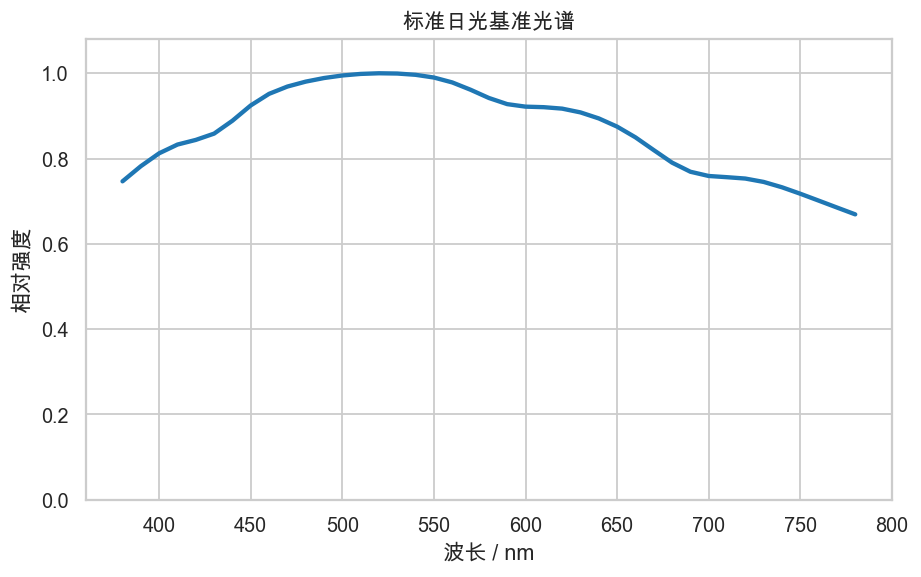

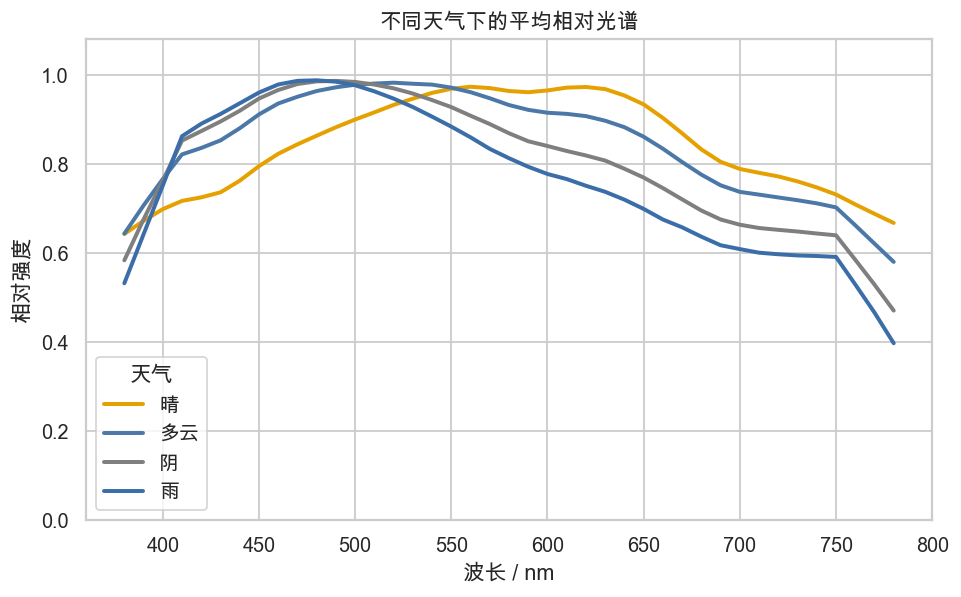

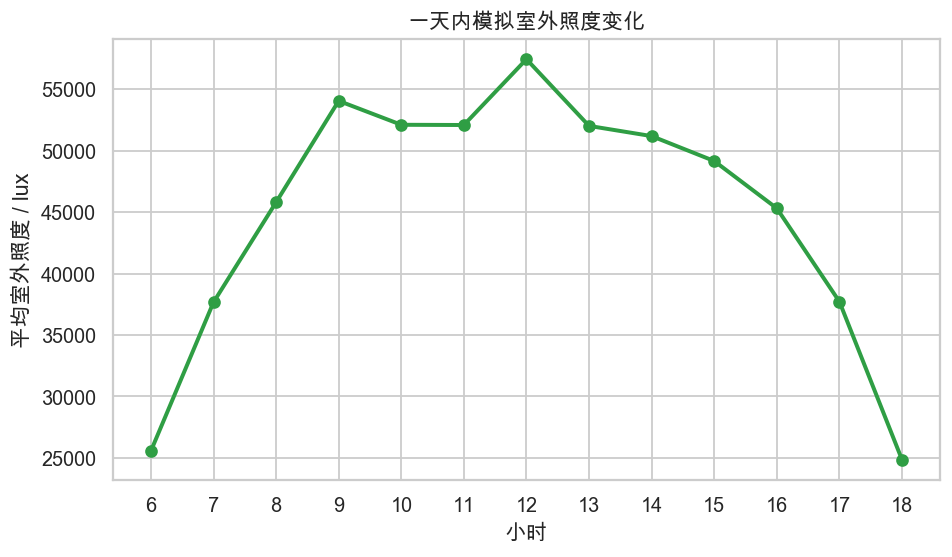

In [3]:
base_df = pd.read_csv('data/base_spectrum.csv', encoding='utf-8-sig')
plot_base_spectrum(base_df)
plt.show()

plot_weather_spectrum_compare(dataset)
plt.show()

plot_hourly_lux(dataset)
plt.show()

## 4. PCA 光谱降维结果

`result.pca` 来自 `sklearn.decomposition.PCA`，下表展示 sklearn PCA 输出的解释方差比例与累计解释方差。

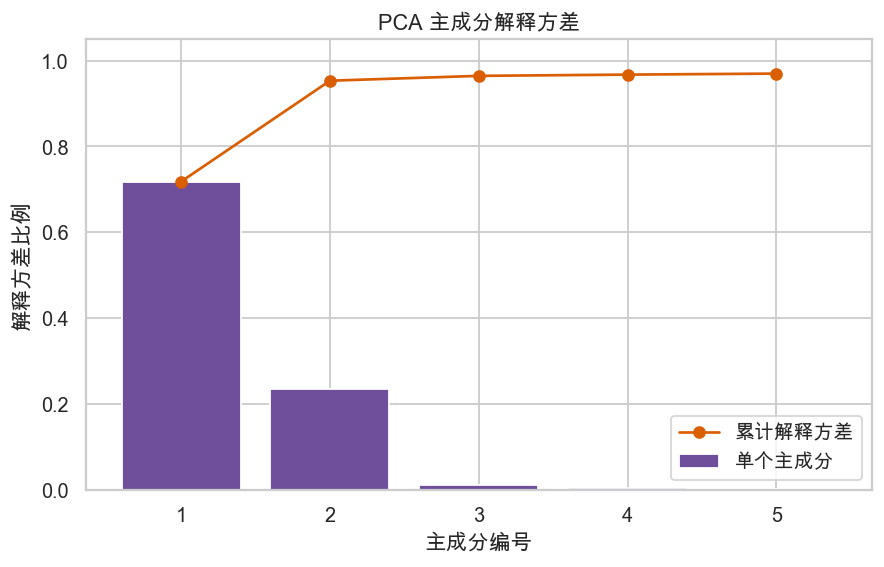

,component,explained_variance_ratio,cumulative_variance_ratio
0,1,0.718074,0.718074
1,2,0.235103,0.953177
2,3,0.011324,0.964501
3,4,0.002897,0.967397
4,5,0.002361,0.969758


In [4]:
plot_pca_variance(result.pca)
plt.show()

pca_table = pd.DataFrame({
    'component': np.arange(1, len(result.pca.explained_variance_ratio_) + 1),
    'explained_variance_ratio': result.pca.explained_variance_ratio_,
    'cumulative_variance_ratio': np.cumsum(result.pca.explained_variance_ratio_),
})
display(pca_table)

## 5. 多模型训练与评价

,model,MAE,RMSE,R2
0,Random Forest,0.011173,0.014105,0.943237
1,KNN Regression,0.011825,0.015083,0.935635
2,Decision Tree,0.012504,0.015892,0.925298
3,Linear Regression,0.014224,0.018069,0.905108


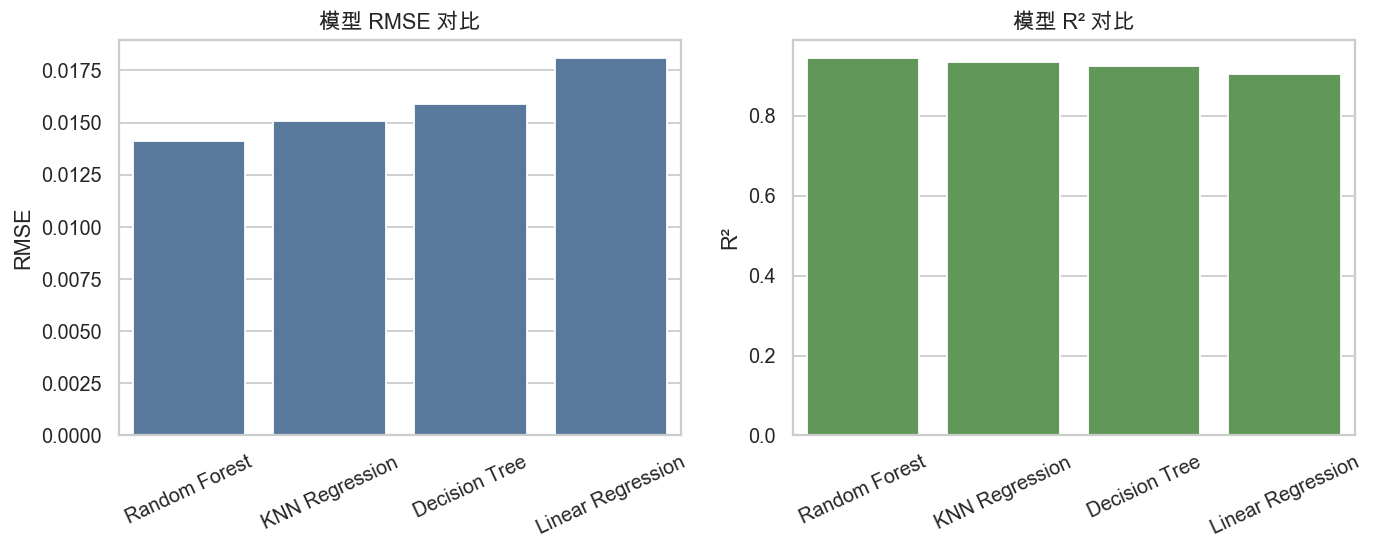

,feature,importance
0,cloud_cover,0.570724
1,solar_altitude,0.267800
2,weather,0.112233
3,outdoor_lux,0.023523
4,precipitation,0.020117
5,humidity,0.003055
6,temperature,0.002013
7,hour,0.000535


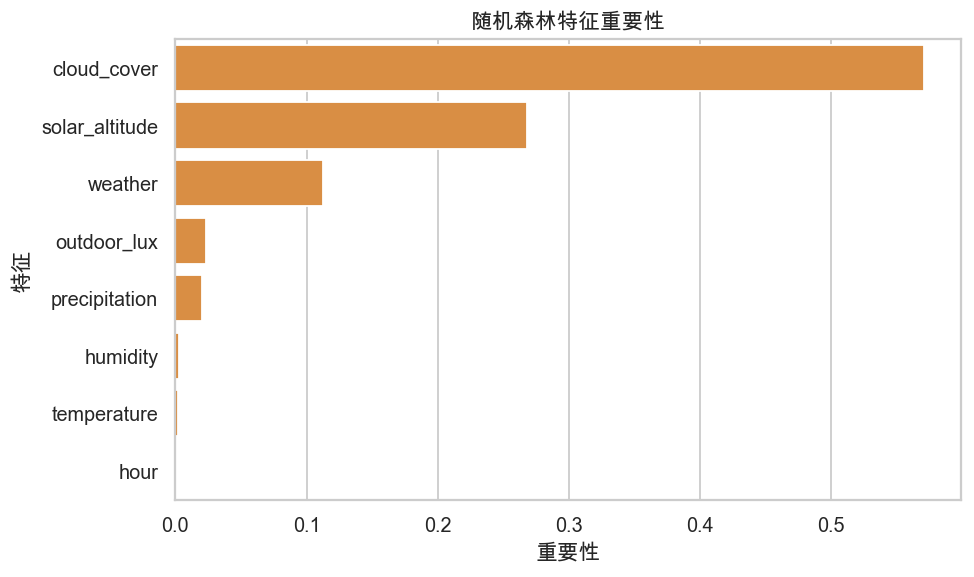

In [5]:
display(result.metrics)
plot_model_compare(result.metrics)
plt.show()

display(result.feature_importance)
plot_feature_importance(result.feature_importance)
plt.show()

## 6. 光谱预测还原效果

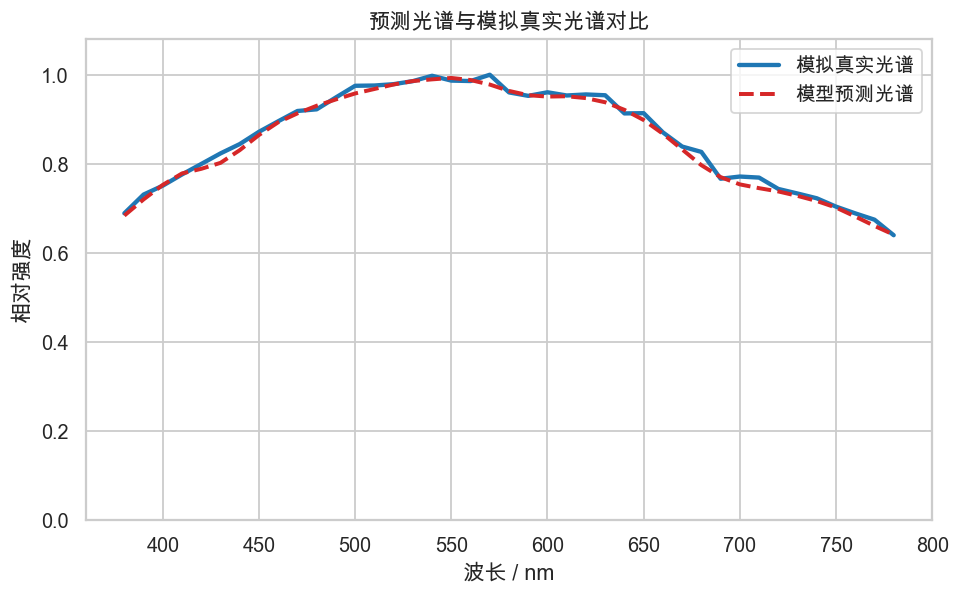

,date,hour,weather,cloud_cover,humidity,solar_altitude,outdoor_lux,scene,target_lux
827,2026-05-09,11,晴,0.1845,0.2929,67.898,81013.62,阅读,400


In [6]:
sample_position = 0
true_spectrum = result.y_test_spectrum[sample_position]
pred_spectrum = result.y_pred_spectrum[sample_position]
plot_prediction_compare(true_spectrum, pred_spectrum)
plt.show()

original_index = int(result.test_indices[sample_position])
display(dataset.loc[[original_index], ['date', 'hour', 'weather', 'cloud_cover', 'humidity', 'solar_altitude', 'outdoor_lux', 'scene', 'target_lux']])

## 7. 外部实测 LED 光谱数据获取

传统双色温灯具不是凭 RGB 颜色直接混出来的，而是由两路白光 LED 的光谱功率分布相加得到。这里使用 Python 下载公开实测 LED SPD CSV，并参考 2700K/6500K 可调白 LED 的常见双通道结构，生成本项目用于对照实验的暖白与冷白通道光谱。

说明：公开 CSV 提供的是商业 LED 实测光谱样本；本项目从中选取蓝光泵浦和宽谱荧光粉型样本，构造课程设计层面的普通双白 LED 光谱近似。它比直接用颜色值模拟更接近真实混光流程。


,用途,来源,链接,说明
0,实测 LED 光谱 CSV,"Harald Brendel, Spectral Power Distribution of...",https://haraldbrendel.com/ledspd.html,29 个商业 LED 的实测 SPD，CSV 覆盖 350-700nm；本项目取蓝光泵浦和宽...
1,双色温灯具结构参考,Bridgelux/L1C1 Vesta tunable white datasheet,https://www.digikey.com/en/htmldatasheets/prod...,公开 datasheet 展示 2700K 到 6500K 可调白 LED 的常见双通道结构...


,wavelength_nm,warm_2700k,cool_6500k
0,380,0.000000,0.000000
1,390,0.000018,0.000010
2,400,0.003745,0.001791
3,410,0.007904,0.006191
4,420,0.040344,0.029641


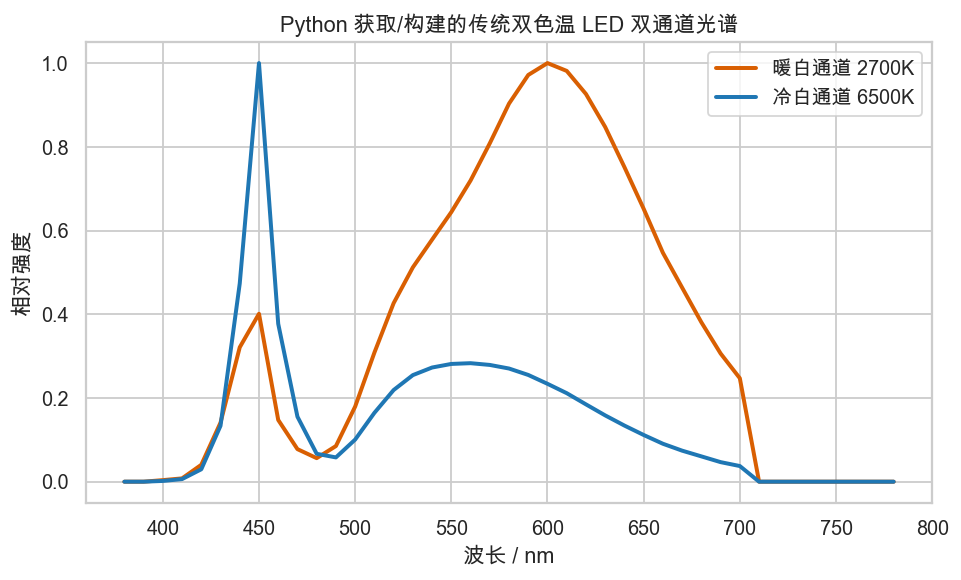

In [7]:
dual_white_df = fetch_and_build_dual_white_spectrum(force=False)
display(source_frame())
display(dual_white_df.head())

plt.figure(figsize=(8.4, 4.6))
plt.plot(dual_white_df['wavelength_nm'], dual_white_df['warm_2700k'], label='暖白通道 2700K', linewidth=2.2, color='#d95f02')
plt.plot(dual_white_df['wavelength_nm'], dual_white_df['cool_6500k'], label='冷白通道 6500K', linewidth=2.2, color='#1f77b4')
plt.title('Python 获取/构建的传统双色温 LED 双通道光谱')
plt.xlabel('波长 / nm')
plt.ylabel('相对强度')
plt.legend()
plt.show()


## 8. 室内七通道 LED 光谱补偿

这一部分不只输出少数几个 LED 比例，而是展示七通道混光系统如何把“预测自然光 + 人工补偿光”拉近到目标光谱。补偿算法保留七个 LED 通道的小比例参与，同时用白光通道提供基础照度、窄带彩色通道负责不同波段的精细修正。本节的传统双色温对照不再直接调 RGB 颜色，而是使用上一节获取/构建的 2700K 暖白和 6500K 冷白光谱真实相加，再统一映射到显示颜色。


典型补偿场景: 学习空间，目标照度 500 lux，室外照度 50000 lux
补偿实验核心指标


,指标,结果
0,自然光占比,0.40
1,有效 LED 通道数,7 / 7
2,补偿前 RMSE,0.5051
3,补偿后 RMSE,0.2360
4,误差下降,53.3%


七通道 LED 输出比例与光谱作用


,通道,峰值波长/nm,推荐比例,输出百分比,光谱作用
0,深蓝/蓝光,445,0.6160,61.6%,补足短波蓝光，影响清醒度和冷感
1,青光,500,0.4603,46.0%,连接蓝光与绿光，平滑中短波过渡
2,绿光,540,0.3688,36.9%,补足视觉敏感区，提高显色稳定性
3,琥珀光,595,0.0551,5.5%,补足黄橙段，改善暖色物体还原
4,红光,635,0.4121,41.2%,补足长波红光，提升暖色与肤色表现
5,暖白,560,0.1843,18.4%,提供暖白基础照度，覆盖黄红连续光谱
6,冷白,505,0.0040,0.4%,提供冷白基础照度，覆盖蓝绿连续光谱


不同波段补偿前后误差对比


,波段,补偿前RMSE,补偿后RMSE,改善幅度
0,短波蓝光 (380-480nm),0.5455,0.2839,48.0%
1,青绿过渡 (480-540nm),0.6056,0.0675,88.9%
2,黄绿敏感区 (540-590nm),0.5529,0.0627,88.7%
3,橙红暖色 (590-680nm),0.4744,0.0894,81.1%
4,深红边缘 (680-780nm),0.3923,0.3446,12.2%


太阳光、预测补偿混光与传统双色温混光颜色对比


,光状态,显示色,相对光谱RMSE
0,目标太阳光,#F8FFFE,0.0000
1,预测补偿混光,#F2FFF2,0.2360
2,传统双色温混光,#FFE3C8,0.3184


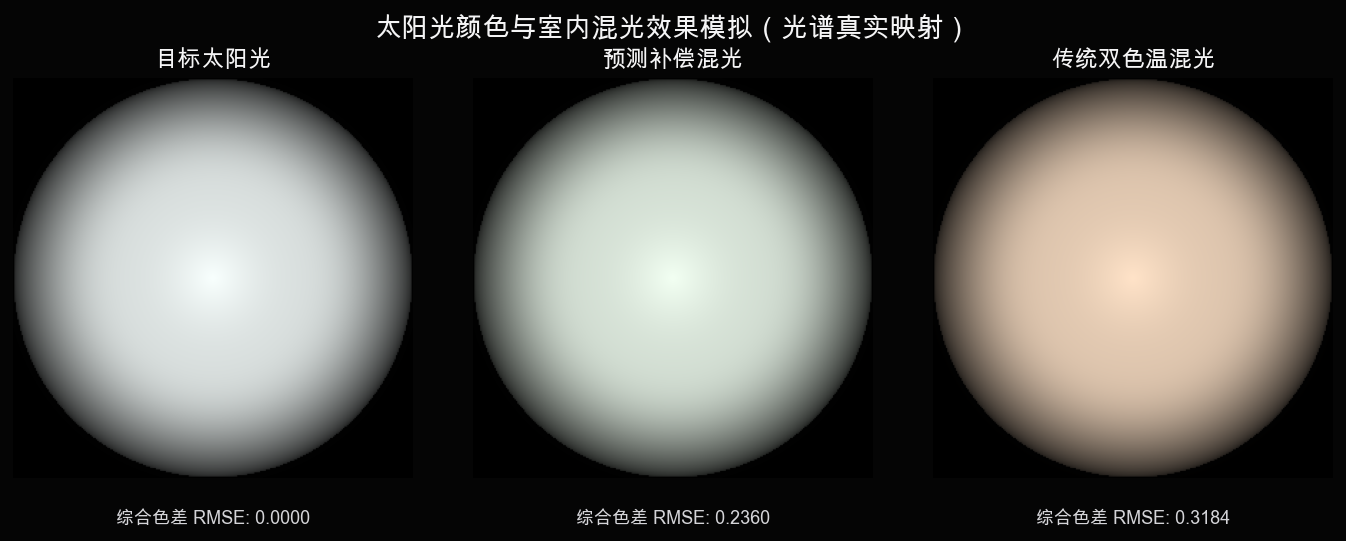

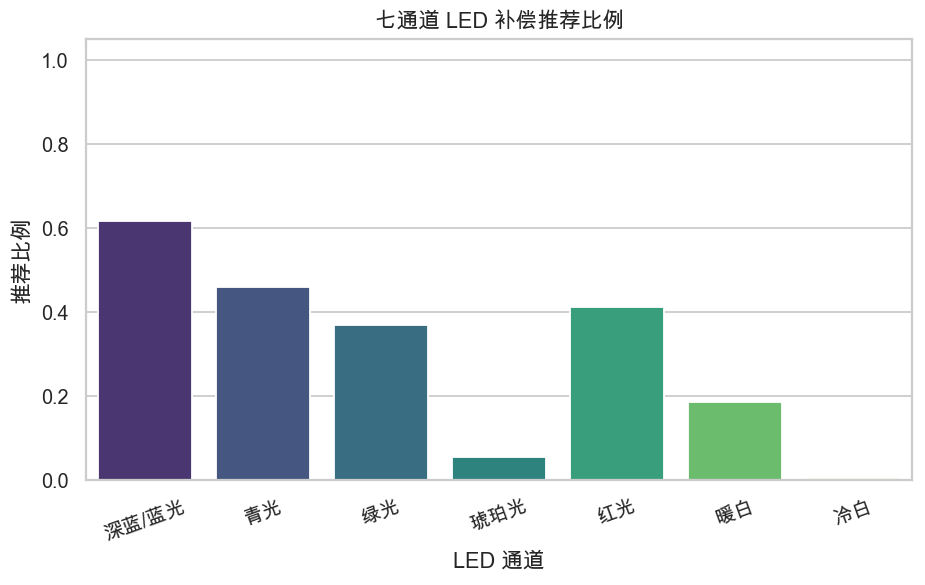

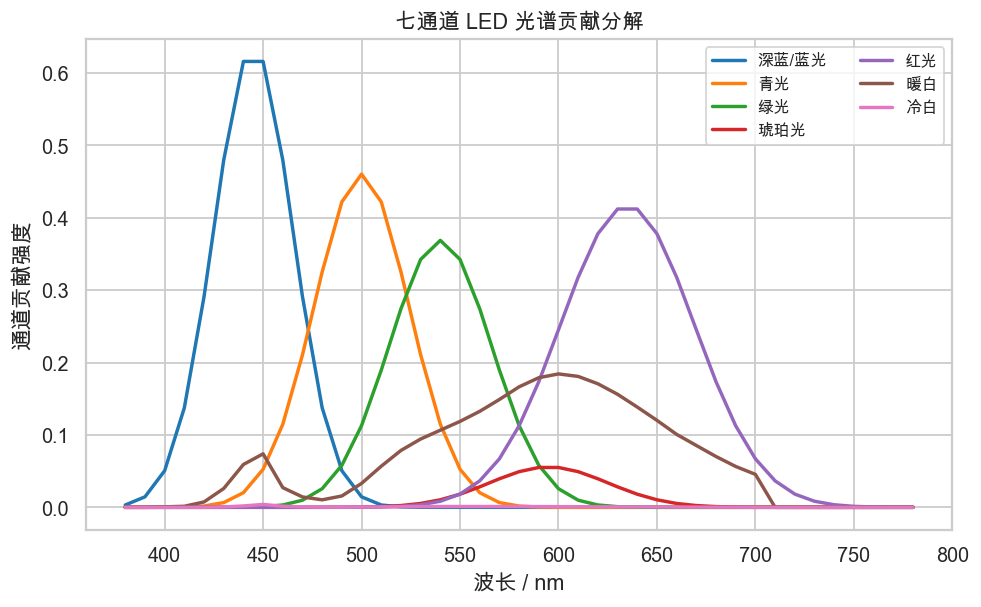

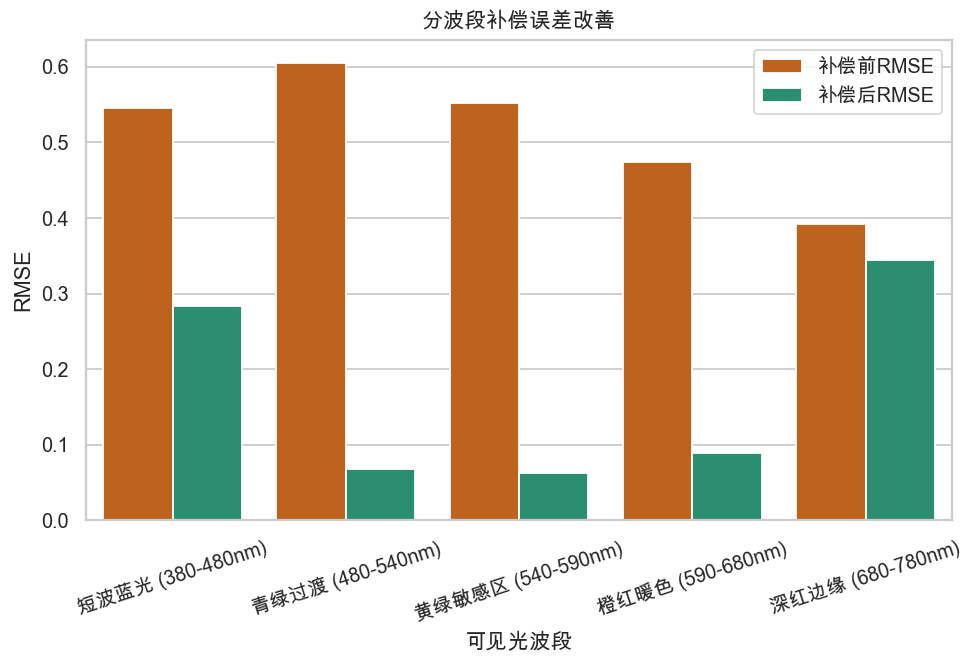

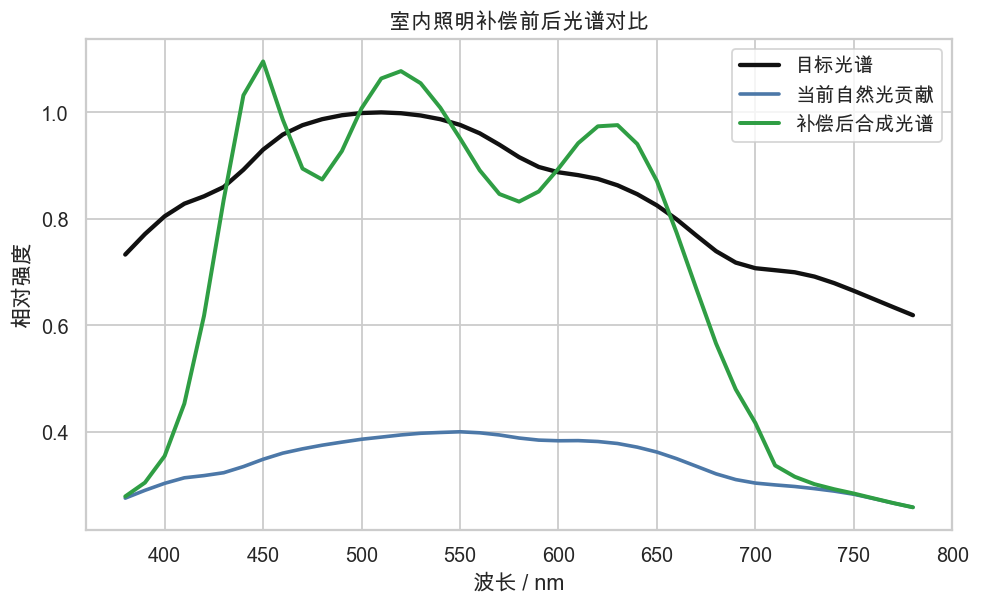

In [8]:
demo_scene = '学习'
demo_target_lux = 500.0
demo_outdoor_lux = 50000.0
compensation = compute_compensation(
    current_spectrum=pred_spectrum,
    scene=demo_scene,
    target_lux=demo_target_lux,
    outdoor_lux=demo_outdoor_lux,
)

print(f'典型补偿场景: {demo_scene}空间，目标照度 {demo_target_lux:.0f} lux，室外照度 {demo_outdoor_lux:.0f} lux')
print('补偿实验核心指标')
display(compensation_summary_frame(compensation))

print('七通道 LED 输出比例与光谱作用')
display(channel_recommendation_frame(compensation.channel_weights))

print('不同波段补偿前后误差对比')
display(band_error_frame(compensation))

print('太阳光、预测补偿混光与传统双色温混光颜色对比')
display(light_color_comparison_frame(compensation))

plot_light_halo_comparison(compensation)
plt.show()

plot_channel_weights(compensation.channel_weights)
plt.show()

plot_channel_contributions(compensation)
plt.show()

plot_band_error_reduction(compensation)
plt.show()

plot_compensation_result(compensation)
plt.show()


## 9. 项目总结

本项目使用标准日光曲线和简化天气规则生成课程设计用模拟数据，通过 scikit-learn 的 PCA 将 41 维光谱压缩为少量主成分，再使用 scikit-learn 的 LinearRegression、KNeighborsRegressor、DecisionTreeRegressor 和 RandomForestRegressor 预测主成分并还原完整光谱。模型对比、PCA 降维、特征重要性和预测结果均基于 sklearn 输出。最后根据预测自然光与目标光谱的差异，计算七通道 LED 的补偿比例。项目重点是流程完整、结果可视、方法可解释，不声称达到真实光学工程级精度。